# Part 2: Data Collection, Processing & Feature Engineering
### *NASA POWER API — All 5 Agricultural Zones of The Gambia (1990–2023)*
  
**Date:** May 2026

---

### What this notebook does

| Step | Task |
|------|------|
| 2.1 | Define the 5 agricultural zones of The Gambia with coordinates |
| 2.2 | Download 30+ years of daily climate data from NASA POWER API |
| 2.3 | Clean the data — handle missing values and out-of-range readings |
| 2.4 | Engineer agronomic features (rolling rainfall, onset indicators, seasonality) |
| 2.5 | Generate binary planting suitability labels using agronomic thresholds |
| 2.6 | Exploratory analysis — visualise seasonal patterns across zones |
| 2.7 | Save the final labelled dataset for use in Part 3 (model training) |

---
## Step 2.1 — Import Libraries

In [2]:
import requests
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker



---
## Step 2.2 — Define The Gambia's 5 Agricultural Zones

The Gambia is divided into five administrative regions, each corresponding to a distinct agricultural zone. We use the centroid coordinates of each region to query the NASA POWER API.

| Zone | Region | Latitude | Longitude | Notes |
|------|--------|----------|-----------|-------|
| Western | Greater Banjul / West Coast | 13.45 | -16.58 | Coastal, higher humidity |
| North Bank | North Bank Region | 13.55 | -15.60 | Mixed farming |
| Lower River | Lower River Region | 13.40 | -15.00 | Groundnut belt |
| Central River | Central River Region | 13.50 | -14.50 | Major millet/sorghum zone |
| Upper River | Upper River Region | 13.47 | -13.80 | Driest zone, rain-critical |

In [3]:
ZONES = {
    'Western':       {'lat': 13.45, 'lon': -16.58},
    'North Bank':    {'lat': 13.55, 'lon': -15.60},
    'Lower River':   {'lat': 13.40, 'lon': -15.00},
    'Central River': {'lat': 13.50, 'lon': -14.50},
    'Upper River':   {'lat': 13.47, 'lon': -13.80},
}

# Date range: 30+ years as required by the proposal
START_DATE = '19900101'
END_DATE   = '20231231'

# NASA POWER parameters (Agroclimatology community)
# PRECTOTCORR  = Precipitation corrected (mm/day)
# T2M_MIN      = Daily minimum temperature at 2m (°C)
# T2M_MAX      = Daily maximum temperature at 2m (°C)
# RH2M         = Relative humidity at 2m (%)
# ALLSKY_SFC_SW_DWN = Solar radiation (MJ/m²/day)
PARAMETERS = 'PRECTOTCORR,T2M_MIN,T2M_MAX,RH2M,ALLSKY_SFC_SW_DWN'

BASE_URL = 'https://power.larc.nasa.gov/api/temporal/daily/point'

print('Zones defined:')
for zone, coords in ZONES.items():
    print(f"  {zone:<16} lat={coords['lat']}, lon={coords['lon']}")
print(f'\nDate range : {START_DATE} → {END_DATE}')
print(f'Parameters : {PARAMETERS}')

Zones defined:
  Western          lat=13.45, lon=-16.58
  North Bank       lat=13.55, lon=-15.6
  Lower River      lat=13.4, lon=-15.0
  Central River    lat=13.5, lon=-14.5
  Upper River      lat=13.47, lon=-13.8

Date range : 19900101 → 20231231
Parameters : PRECTOTCORR,T2M_MIN,T2M_MAX,RH2M,ALLSKY_SFC_SW_DWN


---
## Step 2.3 — Download Data from NASA POWER API

We query the API once per zone. Each request returns daily climate data for the full 1990–2023 period (~12,000 rows per zone).

>  **Expected time:** 1–3 minutes for all 5 zones. The API is free and requires no key.  
> Results are saved to `gambia_climate_raw.csv` so you only need to download once.

In [2]:
def fetch_nasa_power(zone_name, lat, lon, start, end, parameters):
    """
    Fetch daily climate data from NASA POWER API for a single location.
    Returns a clean DataFrame with a DatetimeIndex.
    """
    params = {
        'parameters': parameters,
        'community':  'AG',
        'longitude':  lon,
        'latitude':   lat,
        'start':      start,
        'end':        end,
        'format':     'JSON',
    }

    print(f'  Fetching {zone_name}...', end=' ', flush=True)
    response = requests.get(BASE_URL, params=params, timeout=120)
    response.raise_for_status()

    data = response.json()['properties']['parameter']

    # Each parameter is a dict of {"YYYYMMDD": value}
    df = pd.DataFrame(data)
    df.index = pd.to_datetime(df.index, format='%Y%m%d')
    df.index.name = 'date'

    # Rename columns to readable names
    df = df.rename(columns={
        'PRECTOTCORR':       'rainfall_mm',
        'T2M_MIN':           'temp_min_C',
        'T2M_MAX':           'temp_max_C',
        'RH2M':              'humidity_pct',
        'ALLSKY_SFC_SW_DWN': 'solar_rad_MJm2',
    })

    df['zone'] = zone_name
    df['lat']  = lat
    df['lon']  = lon

    print(f'✓  {len(df):,} rows')
    return df


# ── Download all zones ────────────────────────────────────────────────────────
print('Downloading NASA POWER data for all 5 zones...')
print('=' * 55)

all_zones = []
for zone_name, coords in ZONES.items():
    try:
        df_zone = fetch_nasa_power(
            zone_name, coords['lat'], coords['lon'],
            START_DATE, END_DATE, PARAMETERS
        )
        all_zones.append(df_zone)
        time.sleep(1)   # be respectful to the API
    except Exception as e:
        print(f'  ERROR for {zone_name}: {e}')

# Combine into one DataFrame
raw_df = pd.concat(all_zones).reset_index()

print('=' * 55)
print(f'Total rows downloaded : {len(raw_df):,}')
print(f'Zones                 : {raw_df["zone"].nunique()}')
print(f'Date range            : {raw_df["date"].min().date()} → {raw_df["date"].max().date()}')

# Save raw download
raw_df.to_csv('gambia_climate_raw.csv', index=False)
print('\nRaw data saved → gambia_climate_raw.csv')

NameError: name 'ZONES' is not defined

---
## Step 2.4 — Load & Inspect the Raw Data

If you have already downloaded the data, run this cell to load it from disk instead of re-downloading.

In [5]:
# Load from saved CSV (skip the download cell if re-running)
raw_df = pd.read_csv('gambia_climate_raw.csv', parse_dates=['date'])

print('Shape:', raw_df.shape)
print('\nColumns:', list(raw_df.columns))
print('\nZone counts:')
print(raw_df['zone'].value_counts())
print()
raw_df.head(10)

Shape: (62090, 9)

Columns: ['date', 'rainfall_mm', 'temp_min_C', 'temp_max_C', 'humidity_pct', 'solar_rad_MJm2', 'zone', 'lat', 'lon']

Zone counts:
zone
Western          12418
North Bank       12418
Lower River      12418
Central River    12418
Upper River      12418
Name: count, dtype: int64



,date,rainfall_mm,temp_min_C,temp_max_C,humidity_pct,solar_rad_MJm2,zone,lat,lon
0,1990-01-01,0.00,18.00,26.55,62.04,21.24,Western,13.45,-16.58
1,1990-01-02,0.00,17.83,27.62,57.01,19.67,Western,13.45,-16.58
2,1990-01-03,0.00,18.29,27.42,52.45,19.07,Western,13.45,-16.58
3,1990-01-04,0.00,18.20,27.62,57.70,20.69,Western,13.45,-16.58
4,1990-01-05,0.00,18.90,26.44,58.50,20.52,Western,13.45,-16.58
5,1990-01-06,0.01,18.21,26.49,56.88,20.08,Western,13.45,-16.58
6,1990-01-07,0.02,18.36,25.69,62.84,20.53,Western,13.45,-16.58
7,1990-01-08,0.04,18.18,24.94,54.81,21.42,Western,13.45,-16.58
8,1990-01-09,0.00,18.85,25.18,53.52,21.29,Western,13.45,-16.58
9,1990-01-10,0.00,18.21,24.91,59.30,20.01,Western,13.45,-16.58


---
## Step 2.5 — Data Cleaning

NASA POWER uses **-999** as a fill value for missing data. We:
1. Replace -999 with `NaN`
2. Report how many values are missing per column
3. Forward-fill gaps ≤ 3 days (short sensor outages)
4. Drop any remaining rows with missing values

In [6]:
CLIMATE_COLS = ['rainfall_mm', 'temp_min_C', 'temp_max_C', 'humidity_pct', 'solar_rad_MJm2']

df = raw_df.copy()

# Step 1: Replace NASA fill value (-999) with NaN
df[CLIMATE_COLS] = df[CLIMATE_COLS].replace(-999, np.nan)

# Step 2: Report missing values before cleaning
print('Missing values BEFORE cleaning:')
print(df[CLIMATE_COLS].isnull().sum().to_string())
print(f'  → Total missing: {df[CLIMATE_COLS].isnull().sum().sum():,}')

# Step 3: Forward-fill short gaps (≤3 days) within each zone
df = df.sort_values(['zone', 'date'])
df[CLIMATE_COLS] = (
    df.groupby('zone')[CLIMATE_COLS]
    .transform(lambda x: x.ffill(limit=3))
)

# Step 4: Drop remaining NaN rows
before = len(df)
df = df.dropna(subset=CLIMATE_COLS)
after  = len(df)

print(f'\nMissing values AFTER cleaning : {df[CLIMATE_COLS].isnull().sum().sum()}')
print(f'Rows dropped                  : {before - after:,}')
print(f'Rows remaining                : {len(df):,}')

# Sanity check: rainfall and temperature ranges
print('\nData ranges after cleaning:')
print(df[CLIMATE_COLS].describe().round(2))

Missing values BEFORE cleaning:
rainfall_mm       0
temp_min_C        0
temp_max_C        0
humidity_pct      0
solar_rad_MJm2    0
  → Total missing: 0

Missing values AFTER cleaning : 0
Rows dropped                  : 0
Rows remaining                : 62,090

Data ranges after cleaning:
       rainfall_mm  temp_min_C  temp_max_C  humidity_pct  solar_rad_MJm2
count     62090.00    62090.00    62090.00      62090.00        62090.00
mean          2.36       22.17       33.72         56.21           21.09
std           5.66        3.33        4.87         25.47            3.70
min           0.00        8.99       20.20          5.24            2.43
25%           0.00       19.83       29.92         32.53           19.22
50%           0.00       23.05       32.72         59.68           21.48
75%           2.27       24.46       37.70         81.02           23.76
max         230.37       31.96       46.59         94.82           28.57


---
## Step 2.6 — Feature Engineering

Raw daily climate values are not the best inputs for predicting planting suitability. We engineer agronomically meaningful features as described in the proposal:

| Feature | Description | Agronomic Rationale |
|---------|-------------|---------------------|
| `rain_3d` | 3-day rolling rainfall sum (mm) | Short-term soil moisture signal |
| `rain_7d` | 7-day rolling rainfall sum (mm) | Weekly moisture availability |
| `rain_30d` | 30-day rolling rainfall sum (mm) | Seasonal accumulation |
| `onset_flag` | 1 if rain_3d ≥ 20mm (onset threshold) | Standard West Africa monsoon onset indicator (Sultan & Gaetani, 2016) |
| `temp_mean_C` | Daily mean temperature (°C) | Crop growth temperature window |
| `temp_range_C` | Daily temperature range (°C) | Heat stress indicator |
| `day_of_year` | Day number (1–366) | Seasonality encoding |
| `doy_sin / doy_cos` | Sine & cosine of day_of_year | Circular encoding of season (avoids Jan/Dec discontinuity) |
| `year` | Calendar year | Inter-annual variability |

In [7]:
df = df.sort_values(['zone', 'date']).copy()

# ── Rolling rainfall features (computed within each zone) ─────────────────────
for window in [3, 7, 30]:
    df[f'rain_{window}d'] = (
        df.groupby('zone')['rainfall_mm']
        .transform(lambda x: x.rolling(window, min_periods=window).sum())
    )

# ── Rainfall onset indicator ──────────────────────────────────────────────────
# Standard West African agronomic threshold: ≥20mm over 3 consecutive days
# (Sultan & Gaetani, 2016)
df['onset_flag'] = (df['rain_3d'] >= 20).astype(int)

# ── Temperature features ──────────────────────────────────────────────────────
df['temp_mean_C']  = (df['temp_min_C'] + df['temp_max_C']) / 2
df['temp_range_C'] = df['temp_max_C'] - df['temp_min_C']

# ── Seasonality encoding ──────────────────────────────────────────────────────
df['day_of_year'] = df['date'].dt.dayofyear
df['doy_sin']     = np.sin(2 * np.pi * df['day_of_year'] / 365)
df['doy_cos']     = np.cos(2 * np.pi * df['day_of_year'] / 365)
df['year']        = df['date'].dt.year
df['month']       = df['date'].dt.month

# ── Drop rows with NaN from rolling windows ───────────────────────────────────
before = len(df)
df = df.dropna(subset=['rain_3d', 'rain_7d', 'rain_30d'])
print(f'Rows dropped (rolling window warm-up): {before - len(df):,}')
print(f'Rows after feature engineering       : {len(df):,}')
print()

# Show all engineered features
feature_cols = [
    'rain_3d', 'rain_7d', 'rain_30d', 'onset_flag',
    'temp_mean_C', 'temp_range_C',
    'day_of_year', 'doy_sin', 'doy_cos', 'year'
]
print('Engineered feature preview:')
df[['date', 'zone'] + feature_cols].head(8)

Rows dropped (rolling window warm-up): 145
Rows after feature engineering       : 61,945

Engineered feature preview:


,date,zone,rain_3d,rain_7d,rain_30d,onset_flag,temp_mean_C,temp_range_C,day_of_year,doy_sin,doy_cos,year
37283,1990-01-30,Central River,0.0,0.0,0.01,0,27.055,17.65,30,0.493776,0.869589,1990
37284,1990-01-31,Central River,0.0,0.0,0.01,0,27.180,17.78,31,0.508671,0.860961,1990
37285,1990-02-01,Central River,0.0,0.0,0.01,0,26.775,17.93,32,0.523416,0.852078,1990
37286,1990-02-02,Central River,0.0,0.0,0.01,0,27.030,18.06,33,0.538005,0.842942,1990
37287,1990-02-03,Central River,0.0,0.0,0.01,0,27.510,17.60,34,0.552435,0.833556,1990
37288,1990-02-04,Central River,0.0,0.0,0.01,0,28.900,18.70,35,0.566702,0.823923,1990
37289,1990-02-05,Central River,0.0,0.0,0.01,0,28.665,17.55,36,0.580800,0.814046,1990
37290,1990-02-06,Central River,0.0,0.0,0.01,0,29.220,17.30,37,0.594727,0.803928,1990


---
## Step 2.7 — Generate Planting Suitability Labels

There are no historical records in The Gambia of which days were "good for planting". We generate binary labels using **published agronomic thresholds** from the literature — standard practice when ground-truth records do not exist.

### Labelling Rule

A day is labelled **Suitable (1)** if **all three** conditions are met:

| Condition | Threshold | Source |
|-----------|-----------|--------|
| Rainfall onset | `rain_3d ≥ 20 mm` | Sultan & Gaetani (2016) |
| Minimum seasonal rainfall | `rain_30d ≥ 50 mm` | Standard Sahelian agronomy |
| Temperature in crop window | `20°C ≤ temp_mean_C ≤ 35°C` | Optimal for millet/groundnut |

Otherwise the day is labelled **Not Suitable (0)**.

> **Limitation note (for the report):** Because our labels derive from agronomic rules rather than recorded planting decisions, the model learns to reproduce these rules. This is standard practice and will be clearly noted as a limitation in the final report.

In [8]:
# ── Apply agronomic labelling rules ──────────────────────────────────────────
condition_onset    = df['rain_3d']    >= 20          # monsoon onset threshold
condition_seasonal = df['rain_30d']   >= 50          # adequate seasonal moisture
condition_temp     = (df['temp_mean_C'] >= 20) & (df['temp_mean_C'] <= 35)

df['suitable'] = (
    condition_onset & condition_seasonal & condition_temp
).astype(int)

# ── Label distribution ────────────────────────────────────────────────────────
print('Label distribution (all zones combined):')
counts = df['suitable'].value_counts()
print(f'  Not Suitable (0): {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)')
print(f'  Suitable     (1): {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)')
print()

print('Label distribution by zone:')
zone_labels = (
    df.groupby('zone')['suitable']
    .value_counts(normalize=True)
    .mul(100).round(1)
    .unstack()
    .rename(columns={0: 'Not Suitable (%)', 1: 'Suitable (%)'})
)
print(zone_labels.to_string())

Label distribution (all zones combined):
  Not Suitable (0): 53,689  (86.7%)
  Suitable     (1): 8,256  (13.3%)

Label distribution by zone:
suitable       Not Suitable (%)  Suitable (%)
zone                                         
Central River              86.7          13.3
Lower River                86.2          13.8
North Bank                 85.7          14.3
Upper River                87.0          13.0
Western                    87.7          12.3


---
## Step 2.8 — Exploratory Data Analysis

Three visualisations to understand the data before modelling:
1. **Monthly average rainfall** across all 5 zones — reveals the monsoon season
2. **Planting suitability windows** by zone and month
3. **Inter-annual rainfall variability** for each zone

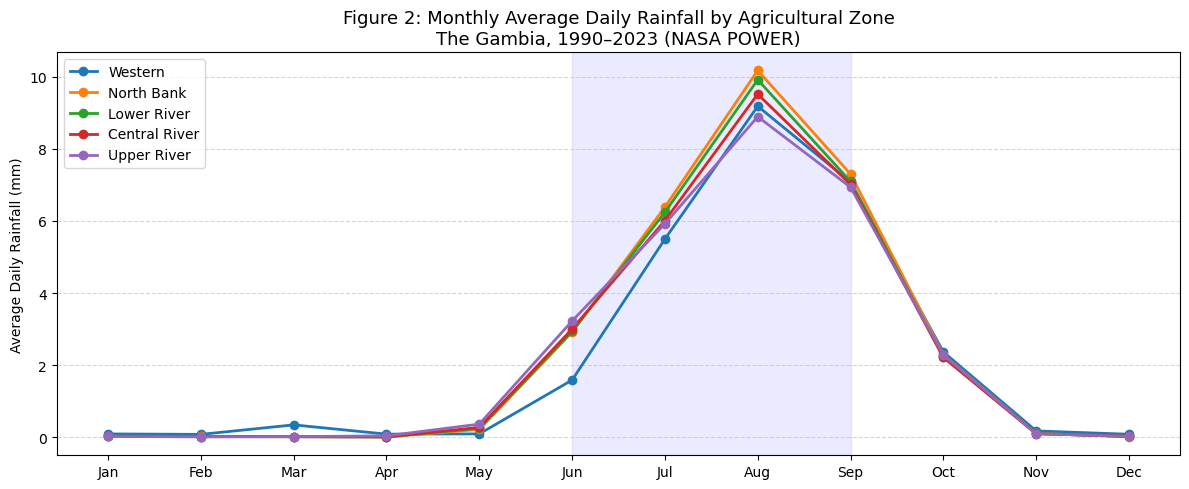

In [9]:
# ── Plot 1: Monthly average rainfall by zone ──────────────────────────────────
monthly_rain = (
    df.groupby(['zone', 'month'])['rainfall_mm']
    .mean()
    .unstack(level=0)
)

fig, ax = plt.subplots(figsize=(12, 5))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, zone in enumerate(ZONES.keys()):
    ax.plot(monthly_rain.index, monthly_rain[zone],
            marker='o', linewidth=2, label=zone, color=colors[i])

ax.set_xticks(range(1, 13))
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_ylabel('Average Daily Rainfall (mm)')
ax.set_title('Figure 2: Monthly Average Daily Rainfall by Agricultural Zone\n'
             'The Gambia, 1990–2023 (NASA POWER)', fontsize=13)
ax.legend(loc='upper left')
ax.axvspan(6, 9, alpha=0.08, color='blue', label='Wet season window')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('fig2_monthly_rainfall_by_zone.png', dpi=150, bbox_inches='tight')
plt.show()

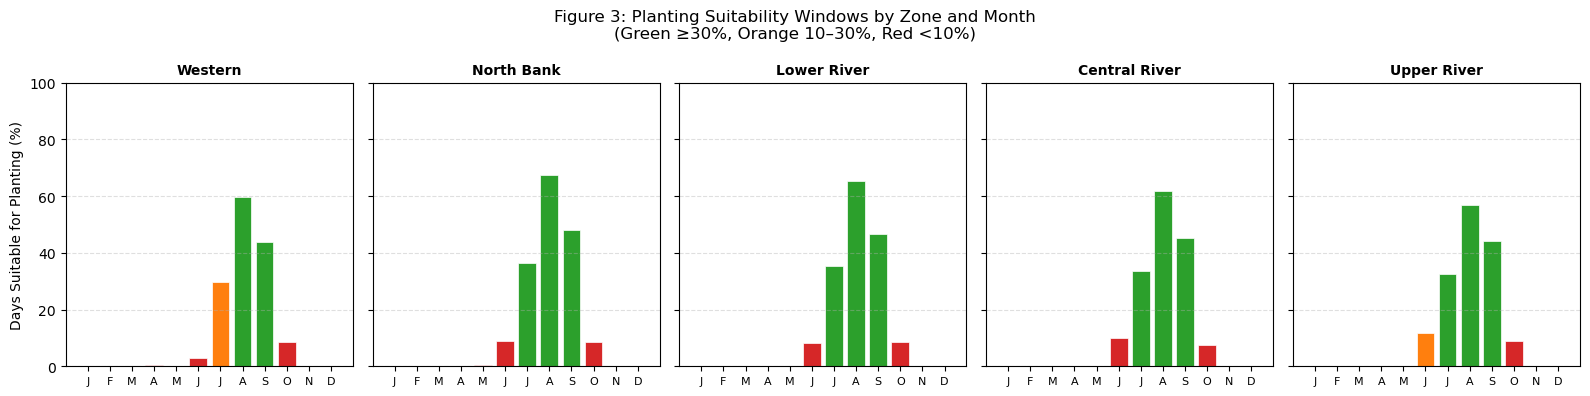

In [10]:
# ── Plot 2: Planting suitability windows by zone and month ────────────────────
suit_monthly = (
    df.groupby(['zone', 'month'])['suitable']
    .mean()
    .mul(100)
    .unstack(level=0)
)

fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
month_labels = ['J','F','M','A','M','J','J','A','S','O','N','D']

for ax, zone in zip(axes, ZONES.keys()):
    values = suit_monthly[zone]
    bars = ax.bar(range(1, 13), values, color=[
        '#2ca02c' if v >= 30 else '#ff7f0e' if v >= 10 else '#d62728'
        for v in values
    ], edgecolor='white', linewidth=0.5)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(month_labels, fontsize=8)
    ax.set_title(zone, fontsize=10, fontweight='bold')
    ax.set_ylim(0, 100)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

axes[0].set_ylabel('Days Suitable for Planting (%)')
fig.suptitle('Figure 3: Planting Suitability Windows by Zone and Month\n'
             '(Green ≥30%, Orange 10–30%, Red <10%)', fontsize=12)
plt.tight_layout()
plt.savefig('fig3_suitability_windows.png', dpi=150, bbox_inches='tight')
plt.show()

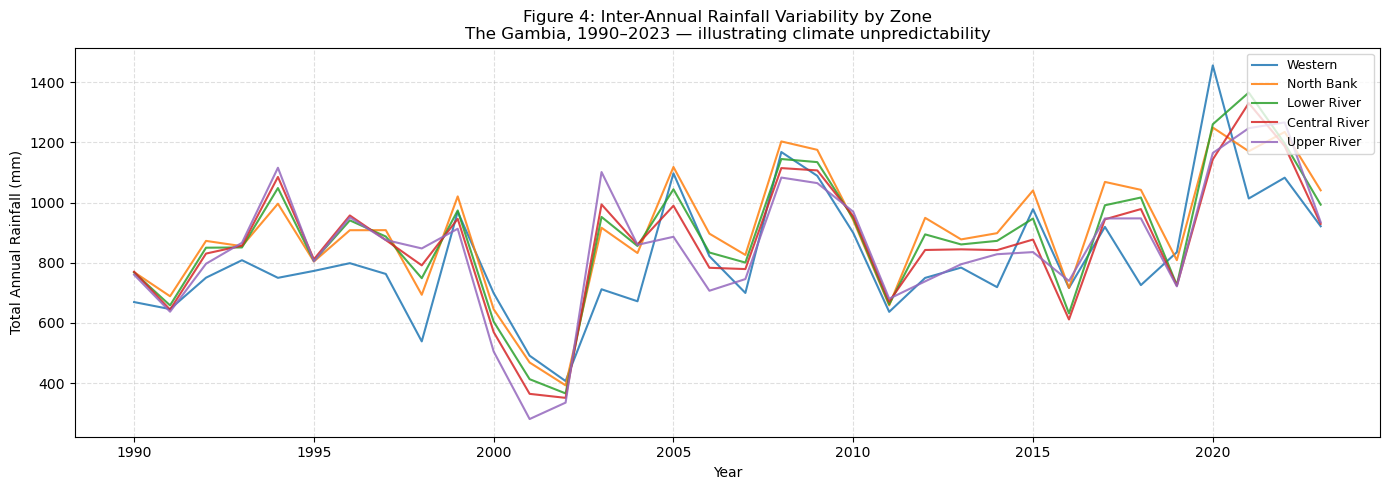

In [11]:
# ── Plot 3: Inter-annual rainfall variability ─────────────────────────────────
annual_rain = (
    df.groupby(['zone', 'year'])['rainfall_mm']
    .sum()
    .unstack(level=0)
)

fig, ax = plt.subplots(figsize=(14, 5))

for i, zone in enumerate(ZONES.keys()):
    ax.plot(annual_rain.index, annual_rain[zone],
            linewidth=1.5, label=zone, color=colors[i], alpha=0.85)

ax.set_xlabel('Year')
ax.set_ylabel('Total Annual Rainfall (mm)')
ax.set_title('Figure 4: Inter-Annual Rainfall Variability by Zone\n'
             'The Gambia, 1990–2023 — illustrating climate unpredictability', fontsize=12)
ax.legend(loc='upper right', fontsize=9)
ax.grid(linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('fig4_interannual_variability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Step 2.9 — Save the Final Labelled Dataset

We select the final feature columns and label, then save to CSV for use in Part 3 (model training).

In [12]:
# Final feature set for modelling
FINAL_FEATURES = [
    'date', 'zone',
    # Raw climate
    'rainfall_mm', 'temp_min_C', 'temp_max_C', 'humidity_pct', 'solar_rad_MJm2',
    # Engineered
    'rain_3d', 'rain_7d', 'rain_30d', 'onset_flag',
    'temp_mean_C', 'temp_range_C',
    'day_of_year', 'doy_sin', 'doy_cos', 'year', 'month',
    # Label
    'suitable'
]

final_df = df[FINAL_FEATURES].copy()

# Save
final_df.to_csv('gambia_labelled_dataset.csv', index=False)

print('Final dataset saved → gambia_labelled_dataset.csv')
print(f'Shape  : {final_df.shape}')
print(f'Zones  : {final_df["zone"].nunique()}')
print(f'Dates  : {final_df["date"].min().date()} → {final_df["date"].max().date()}')
print(f'Label  : {final_df["suitable"].value_counts().to_dict()}')
print()
final_df.head()

Final dataset saved → gambia_labelled_dataset.csv
Shape  : (61945, 19)
Zones  : 5
Dates  : 1990-01-30 → 2023-12-31
Label  : {0: 53689, 1: 8256}



,date,zone,rainfall_mm,temp_min_C,temp_max_C,humidity_pct,solar_rad_MJm2,rain_3d,rain_7d,rain_30d,onset_flag,temp_mean_C,temp_range_C,day_of_year,doy_sin,doy_cos,year,month,suitable
37283,1990-01-30,Central River,0.0,18.23,35.88,24.09,17.48,0.0,0.0,0.01,0,27.055,17.65,30,0.493776,0.869589,1990,1,0
37284,1990-01-31,Central River,0.0,18.29,36.07,26.30,18.69,0.0,0.0,0.01,0,27.180,17.78,31,0.508671,0.860961,1990,1,0
37285,1990-02-01,Central River,0.0,17.81,35.74,29.22,19.40,0.0,0.0,0.01,0,26.775,17.93,32,0.523416,0.852078,1990,2,0
37286,1990-02-02,Central River,0.0,18.00,36.06,27.87,19.91,0.0,0.0,0.01,0,27.030,18.06,33,0.538005,0.842942,1990,2,0
37287,1990-02-03,Central River,0.0,18.71,36.31,30.62,21.64,0.0,0.0,0.01,0,27.510,17.60,34,0.552435,0.833556,1990,2,0


---


**Output file:** `gambia_labelled_dataset.csv` — ready for Part 3: Random Forest classifier training.

---

## References

NASA POWER Project. (2024). *Prediction of Worldwide Energy Resources*. National Aeronautics and Space Administration. https://power.larc.nasa.gov

Sultan, B., & Gaetani, M. (2016). Agriculture in West Africa in the twenty-first century: Climate change and impacts scenarios, and potential for adaptation. *Frontiers in Plant Science*, 7, 1262. https://doi.org/10.3389/fpls.2016.01262